# Experimentation for "Feature Relevancy, Necessity and Usefulness: Complexity and Algorithms"

In this notebook we present tools to reproduce the experimentation from the paper _Feature Relevancy, Necessity and Usefulness: Complexity and Algorithms_.

### Dependencies

In [2]:
import math
import numpy as np
from copy import deepcopy
import random
import warnings
import pickle

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import KBinsDiscretizer, OrdinalEncoder

import seaborn as sns

import shap

/home/scifuentes/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experiment 1: Computation of scores

We compute the usefulness score for three different datasets, training 20 different decission trees, and using different numbers of bins for making the features categorical.

### Code to train the models

In [2]:
## Train a tree for the California Housing Dataset
def train_tree_for_California(max_depth, seed, bins, random_state, leaves=1000000):
    column_names = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']
    
    X = deepcopy(housing.data)
    y = deepcopy(housing.target)

    # We booleanize the prediction by taking the median as a threshold
    median_value = np.median(y)
    y_binary = (y > median_value).astype(int)

    # We make all other features categorical
    kbins = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='quantile')
    X_binned = kbins.fit_transform(X)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X_binned, y_binary, test_size=0.2, random_state=seed)

    # Train a Decision Tree classifier
    clf = DecisionTreeClassifier(random_state=random_state, max_depth=max_depth, max_leaf_nodes=leaves)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    features_to_domain = {}
    for feat in column_names:
        features_to_domain[feat] = (0, bins-1)
    
    return clf, accuracy, features_to_domain, pd.DataFrame(X_train, columns=column_names)

## Train a tree for the Bike Sharing Dataset
def train_tree_for_Bikes(max_depth, seed, bins, random_state, leaves=1000000):
    df = bike_sharing_dataset.copy(deep=True)

    # Drop target column and unnecessary columns from X axis; set target column
    X = df.drop(["cnt"], axis=1)
    y = df["cnt"]

    # We booleanize the prediction by taking the median as a threshold
    median_value = np.median(y)
    y_binary = (y > median_value).astype(int)

    # We make all other features categorical
    features_to_bin = ["mnth", "hr", "weekday", "temp", "atemp", "hum", "windspeed"]
    kbins = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='quantile')
    binned_data = kbins.fit_transform(X[features_to_bin])

    for idx, col in enumerate(features_to_bin):
        df[col + "_binned"] = binned_data[:, idx].astype(int)

    X = df.drop(columns=features_to_bin + ["cnt"], axis=1)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=seed)

    # Train a Decision Tree classifier
    clf = DecisionTreeClassifier(random_state=random_state, max_depth=max_depth, max_leaf_nodes=leaves)
    clf.fit(X_train, y_train)

    # Evaluate the classifier
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    features_to_domain = {}
    for feat in features_to_bin:
        features_to_domain[feat + "_binned"] = (0, bins-1)

    features_to_domain["season"] = (0, 1)
    features_to_domain["yr"] = (0, 1)
    features_to_domain["holiday"] = (0, 1)
    features_to_domain["workingday"] = (0, 1)
    features_to_domain["weathersit"] = (0, 4)
    
    return clf, accuracy, features_to_domain, list(X.keys())

## Train a tree for the Adult Income Dataset
def train_tree_for_Adult_Income(max_depth, seed, bins, random_state, leaves=100000):
    column_names = [
        "age", "workclass", "fnlwgt", "education", "education-num",
        "marital-status", "occupation", "relationship", "race", "sex",
        "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
    ]
    
    df = adult_income_dataset.copy(deep=True)
    X = df.drop("income", axis=1)
    y = df["income"]
    
    features_to_categorize = ["age", "fnlwgt", "workclass", "education", "education-num", "marital-status",
        "occupation", "relationship", "capital-gain", "capital-loss", "hours-per-week", "native-country"]
    features_categorical = ["race", "sex"]
    all_features = features_to_categorize + features_categorical
    
    # Step 4: Discretize *all* features into categorical bins
    # We'll use 5 bins, and encode as ordinal integers (like categories)
    kbins = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='uniform')
    binned_data = kbins.fit_transform(X[features_to_categorize])

    for idx, col in enumerate(features_to_categorize):
        df[col + "_binned"] = binned_data[:, idx].astype(int)

    X = df.drop(columns=features_to_categorize + ["income"], axis=1)

    # Step 5: Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    
    # Step 6: Train a Decision Tree Classifier
    clf = DecisionTreeClassifier(random_state=random_state, max_depth=max_depth, max_leaf_nodes=leaves)
    clf.fit(X_train, y_train)
    
    # Step 7: Evaluate
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    features_to_domain = {}
    for feat in features_to_categorize:
        features_to_domain[feat + "_binned"] = (0, bins-1)
    features_to_domain["race"] = (0, 4)
    features_to_domain["sex"] = (0, 1)

    return clf, acc, features_to_domain, list(X.keys())

### Load the datasets

In [ ]:

# Load the California Housing Dataset
housing = fetch_california_housing(as_frame=True)

# Load the Bike Sharing Dataset
bike_sharing_dataset = pd.read_csv("datasets/bike_sharing/hour.csv")
bike_sharing_dataset = bike_sharing_dataset.drop(["casual", "registered", "instant", "dteday"], axis=1)

# Load the adult income dataset
column_names = [
        "age", "workclass", "fnlwgt", "education", "education-num",
        "marital-status", "occupation", "relationship", "race", "sex",
        "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
    ]
features_to_categorize = ["age", "workclass", "education", "education-num", "marital-status",
        "occupation", "relationship", "capital-gain", "capital-loss", "hours-per-week", "native-country"]
features_categorical = ["race", "sex"]
    
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
adult_income_dataset = pd.read_csv(url, names=column_names, na_values=" ?", skipinitialspace=True)

# Strip leading/trailing spaces from string columns
columns_with_question = ["workclass", "occupation", "native-country"]
for col in columns_with_question:
    adult_income_dataset = adult_income_dataset[adult_income_dataset[col] != "?"]
adult_income_dataset.dropna(inplace=True)

# Encode categorical features as ordinal integers
encoder = OrdinalEncoder()
adult_income_dataset[column_names] = encoder.fit_transform(adult_income_dataset[column_names])

### Code to compute the usefullness score

In [3]:
## Class to represent nodes of the decision trees
class Node:
    feature = None
    threshold = None
    left = None
    right = None

    def __init__(self, feature, threshold, left, right):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

    def get_feature(self):
        return self.feature

    def set_feature(self, new_feature):
        old_feature = self.feature
        self.feature = new_feature
        return old_feature

    def get_threshold(self):
        return self.threshold

    def set_threshold(self, new_threshold):
        old_threshold = self.threshold
        self.threshold = new_threshold
        return old_threshold

    def get_left(self):
        return self.left

    def set_left(self, node):
        self.left = node

    def get_right(self):
        return self.right

    def set_right(self, node):
        self.right = node

    def is_leaf(self):
        return self.left == None

    def is_true(self):
        return self.feature == "True"

    def is_false(self):
        return not self.is_true()

## Internal representation of decision trees
class Tree:
    root = None
    domains = None

    def __init__(self, root, domains):
        self.root = root
        self.domains = domains

    def get_root(self):
        return self.root

    def _count_recursive(self, node, ranges):
        if node.is_leaf() and node.is_true():
            fail = False
            acum = 1
            for (a, b) in ranges.values():
                if b < a:
                    return 0
                acum = acum * (math.floor(b) - math.ceil(a) + 1)
            #print(ranges)
            #print(acum)
            if acum < 0:
                print(ranges)
            return acum

        elif not node.is_leaf():
            acum = 0
            
            cur_feature = node.get_feature()
            cur_threshold = node.get_threshold()

            a, b = ranges[cur_feature]

            ranges[cur_feature] = (a, min(cur_threshold, b))
            acum += 0 if min(cur_threshold, b) < a else self._count_recursive(node.get_left(), ranges)

            ranges[cur_feature] = (max(cur_threshold + 0.0000001, a), b)
            acum += 0 if b < max(cur_threshold + 0.0000001, a) else self._count_recursive(node.get_right(), ranges)

            ranges[cur_feature] = (a, b)
            return acum

        else:
            return 0
                
    
    def count(self):
        ranges = {feature: self.domains[feature] for feature in self.domains.keys()}
        
        return self._count_recursive(self.root, ranges)

    def _negate_recursive(self, node):
        if node.is_leaf():
            if node.get_feature() == "True":
                node.set_feature("False")
            else:
                node.set_feature("True")

        else:
            self._negate_recursive(node.get_left())
            self._negate_recursive(node.get_right())
    
    def negate(self):
        return self._negate_recursive(self.root)

    def _conjunction_recursive(self, node, prev_node, other_tree):
        if node.is_leaf():
            if node.is_true():
                if prev_node.get_right() == node:
                    prev_node.set_right(other_tree.get_root())
                else:
                    prev_node.set_left(other_tree.get_root())
        else:
            self._conjunction_recursive(node.get_left(), node, other_tree)
            self._conjunction_recursive(node.get_right(), node, other_tree)

    # Never use more than once in the same tree: we store references instead of copies to avoid using quadratic memory.
    def conjunction(self, other_tree):
        return self._conjunction_recursive(self.root, None, other_tree)

    def _condition_recursive(self, node, feature, value):
        if node.is_leaf():
            return
        else:
            if node.get_feature() == feature:
                if value <= node.get_threshold():
                    node.set_threshold(1e9)
                else:
                    node.set_threshold(-1)

            self._condition_recursive(node.get_left(), feature, value)
            self._condition_recursive(node.get_right(), feature, value)
                
    
    def condition(self, feature, value):
        self._condition_recursive(self.root, feature, value)
    
    def _print_recursive(self, node, tabs):
        if node == None:
            return
        else:
            space = " " * tabs
            print(f'{space}{node.get_feature()} (<= {node.get_threshold()})')
            self._print_recursive(node.get_left(), tabs+3)
            self._print_recursive(node.get_right(), tabs+3)
            
    def print(self):
        self._print_recursive(self.root, 0)

def dec_tree_to_my_tree_rec(node, dec_tree, features):
    if dec_tree.tree_.feature[node] != -2:  # Not a leaf
        feature_name = features[dec_tree.tree_.feature[node]]
        left_node = dec_tree_to_my_tree_rec(dec_tree.tree_.children_left[node], dec_tree, features)
        right_node = dec_tree_to_my_tree_rec(dec_tree.tree_.children_right[node], dec_tree, features)
        threshold = clf.tree_.threshold[node]
        return Node(feature_name, threshold, left_node, right_node)
    else:
        value = dec_tree.tree_.value[node]
        predicted_class = np.argmax(value)
        if predicted_class == 1:
            return Node("True", 1, None, None)
        else:
            return Node("False", 0, None, None)

## Code to translate SKlearn trees to ours
def dec_tree_to_my_tree(dec_tree, domains, features):
    root = dec_tree_to_my_tree_rec(0, dec_tree, features)
    return Tree(root, domains)

## Code to compute scores
def compute_score(tree, feature, num_features, domains):
    tree_0 = deepcopy(tree)
    tree_0.condition(feature, 0)
    for val in range(domains[feature][0]+1, domains[feature][1] + 1):
        tree_next = deepcopy(tree)
        tree_next.condition(feature, val)
        tree_next.conjunction(tree_0)
        tree_0 = tree_next
        #tree_0.print()

    acum = tree_0.count()

    negated_tree_0 = deepcopy(tree)
    negated_tree_0.negate()
    negated_tree_0.condition(feature, 0)
    for val in range(domains[feature][0]+1, domains[feature][1] + 1):
        tree_next = deepcopy(tree)
        tree_next.condition(feature, val)
        tree_next.negate()
        tree_next.conjunction(negated_tree_0)
        negated_tree_0 = tree_next

    acum += negated_tree_0.count()

    total = 1
    for feature in features:
        a, b = domains[feature]
        total *= (math.floor(b) - math.ceil(a) + 1)
    
    return total - acum

### Computing the scores
#### California Housing Dataset

In [14]:
random.seed(42)

for bins in range(3, 7):
    tries = 20
    
    _, _, domains, _ = train_tree_for_California(2, 42, 3, 42)
    features = list(domains.keys())
    
    scores = {feature: [] for feature in features}
    accuracies = []
    
    for i in range(tries):
        random_value = random.randint(0, 100000)
        clf, accuracy, domains, _ = train_tree_for_California(100000, random_value, bins, random_value, 100*bins)
        
        tree = dec_tree_to_my_tree(clf, domains, features)
        
        for feature in features:
            scores[feature].append(compute_score(tree, feature, len(features), domains))
        accuracies.append(accuracy)
    
    stats = []
    for k, v in scores.items():
        q1 = np.percentile(v, 25)
        med = np.median(v)
        q3 = np.percentile(v, 75)
        stats.append((k, q1, med, q3))
    
    # Sort by median
    stats.sort(key=lambda x: x[2])
    labels, q1s, meds, q3s = zip(*stats)
    with open(f"results/california_bins_{bins}", "wb+") as file:
        pickle.dump([labels, q1s, meds, q3s, accuracies], file)
    print(f'Finished {bins} bins') 

Finished 3 bins
Finished 4 bins
Finished 5 bins
Finished 6 bins


#### Bike Sharing Dataset

In [7]:
random.seed(42)

for bins in range(3, 7):
    tries = 20
    
    _, _, _, features = train_tree_for_Bikes(4, 420, 3, 420, 4)
    scores = {feature: [] for feature in features}
    accuracies = []
    
    for i in range(tries):
        random_value = random.randint(0, 100000)
        clf, accuracy, domains, features = train_tree_for_Bikes(2000000, random_value, bins, random_value, 100*bins)
        
        tree = dec_tree_to_my_tree(clf, domains, features)
        
        for feature in features:
            scores[feature].append(compute_score(tree, feature, len(features), domains))
        accuracies.append(accuracy)
    
    stats = []
    for k, v in scores.items():
        q1 = np.percentile(v, 25)
        med = np.median(v)
        q3 = np.percentile(v, 75)
        stats.append((k, q1, med, q3))
    
    # Sort by median
    stats.sort(key=lambda x: x[2])
    labels, q1s, meds, q3s = zip(*stats)
    with open(f"results/bike_sharing_bins_{bins}", "wb+") as file:
        pickle.dump([labels, q1s, meds, q3s, accuracies], file)
    print(f'Finished {bins} bins') 

Finished 3 bins
Finished 4 bins
Finished 5 bins
Finished 6 bins


#### Adult Income Dataset

In [8]:
random.seed(42)

for bins in range(3, 7):
    tries = 20
    
    _, _, _, features = train_tree_for_Adult_Income(4, 420, 3, 420, 4)
    scores = {feature: [] for feature in features}
    accuracies = []
    
    for i in range(tries):
        random_value = random.randint(0, 100000)
        clf, accuracy, domains, features = train_tree_for_Adult_Income(200000, random_value, bins, random_value, 150*bins)
        
        tree = dec_tree_to_my_tree(clf, domains, features)
        
        for feature in features:
            scores[feature].append(compute_score(tree, feature, len(features), domains))
        accuracies.append(accuracy)
    
    stats = []
    for k, v in scores.items():
        q1 = np.percentile(v, 25)
        med = np.median(v)
        q3 = np.percentile(v, 75)
        stats.append((k, q1, med, q3))
    
    # Sort by median
    stats.sort(key=lambda x: x[2])
    labels, q1s, meds, q3s = zip(*stats)
    with open(f"results/california_bins_{bins}", "wb+") as file:
        pickle.dump([labels, q1s, meds, q3s, accuracies], file)
    print(f'Finished {bins} bins') 

Finished 3 bins
Finished 4 bins
Finished 5 bins
Finished 6 bins


### Plotting the results

0.8515391254315305


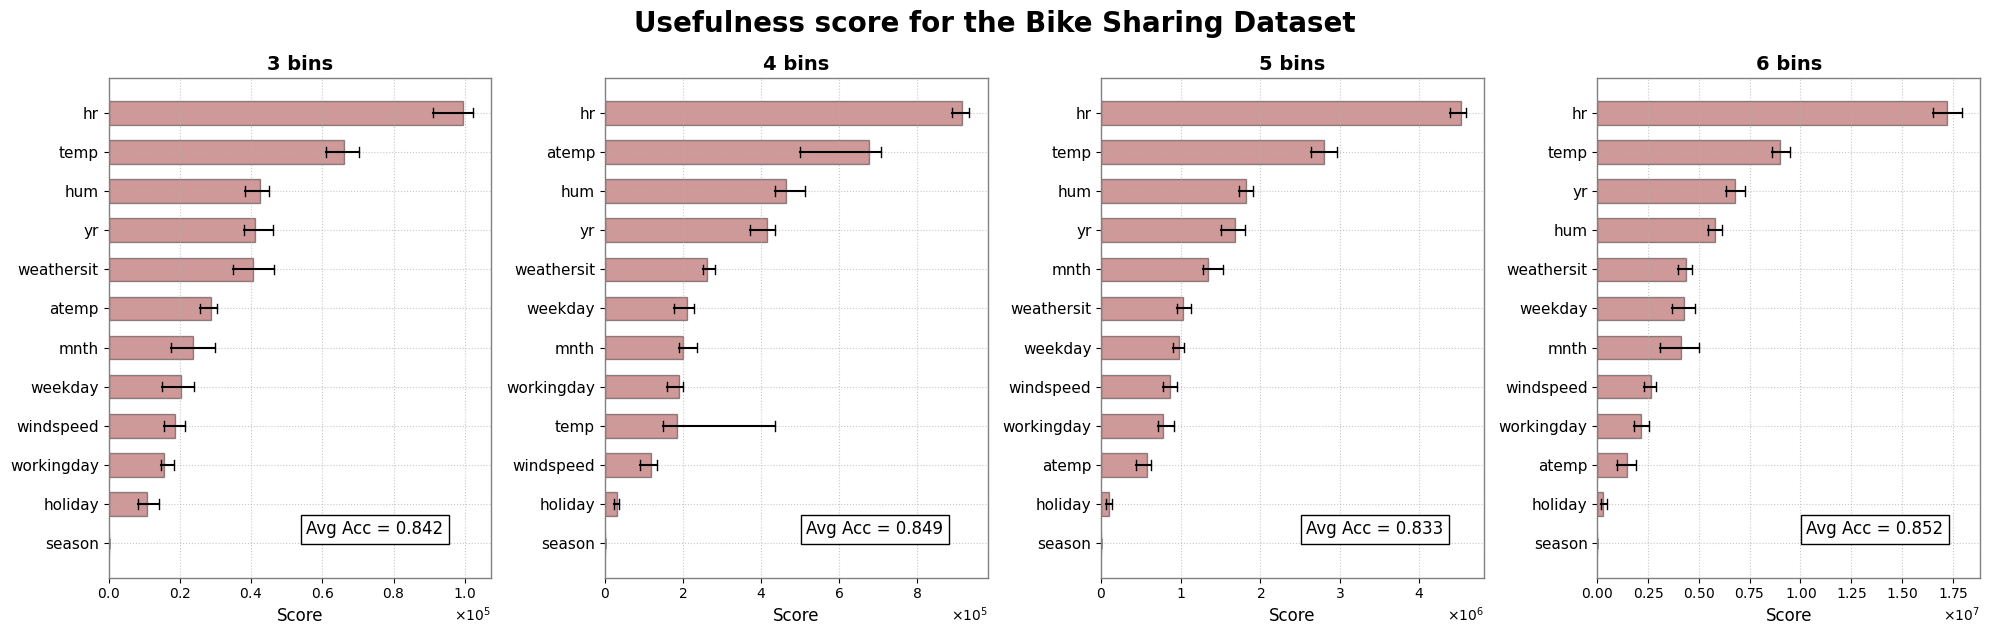

In [12]:
dataset = "bike_sharing"
color_for_dataset = {"california": "steelblue", "adult_income": "darkorange", "bike_sharing": "darkred"}

# 1x4 grid instead of 2x2
fig, axs = plt.subplots(1, 4, figsize=(20, 6), sharex=False, sharey=False)

bins_num = [3, 4, 5, 6]
accr = []

for i, bins in enumerate(bins_num):
    ax = axs[i]

    # Read the lists from the file
    with open("results/" + dataset + f"_bins_{bins}", 'rb') as file:
        loaded_lists = pickle.load(file)
    
    labels, q1s, meds, q3s, accuracies = loaded_lists
    labels = [label.replace("_binned", "") for label in labels]
    y_pos = np.arange(len(labels))

    # Main horizontal bars at median
    ax.barh(y_pos, meds, color=color_for_dataset[dataset], alpha=0.4, edgecolor='black', height=0.6)
    
    bar_height = 0.6
    line_height = bar_height * 0.4  # 40% of full bar height
    for y, q1, q3 in zip(y_pos, q1s, q3s):
        # Short horizontal line for Q1–Q3
        ax.plot([q1, q3], [y, y], color='black', linewidth=1.5)
    
        # Small vertical ticks at Q1 and Q3
        ax.plot([q1, q1], [y - line_height / 2, y + line_height / 2], color='black', linewidth=1)
        ax.plot([q3, q3], [y - line_height / 2, y + line_height / 2], color='black', linewidth=1)

    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
    
    # Style
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('Score', fontsize=12)
    ax.set_title(f'{bins} bins', fontsize=14, fontweight='semibold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', linewidth=0.8, alpha=0.7)
    ax.tick_params(axis='x', labelsize=10)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color('grey')

    accr.append(np.mean(accuracies))

print(np.mean(accuracies))

# Adjust annotation positions for horizontal layout
x_positions = [0.19, 0.44, 0.69, 0.94]
for i, xpos in enumerate(x_positions):
    fig.text(xpos, 0.2, f'Avg Acc = {accr[i]:.3f}',
             fontsize=12,
             va='top', ha='center',
             bbox=dict(facecolor='white', edgecolor='black'))

plt.tight_layout()

titles = {"california": "California Housing", "adult_income": "Adult Income", "bike_sharing": "Bike Sharing"}

fig.suptitle("Usefulness score for the " + titles[dataset] + " Dataset", fontsize=20, fontweight='semibold', y=1.05)
fig.savefig(dataset + '.pdf', format='pdf', bbox_inches='tight')

## Experiment 2: Comparing usefulness with shap

We train 20 models for each dataset, each one with 6 bins, and for each one of these models we compare the ranking induced by the usefulness score with the one induced by shap.

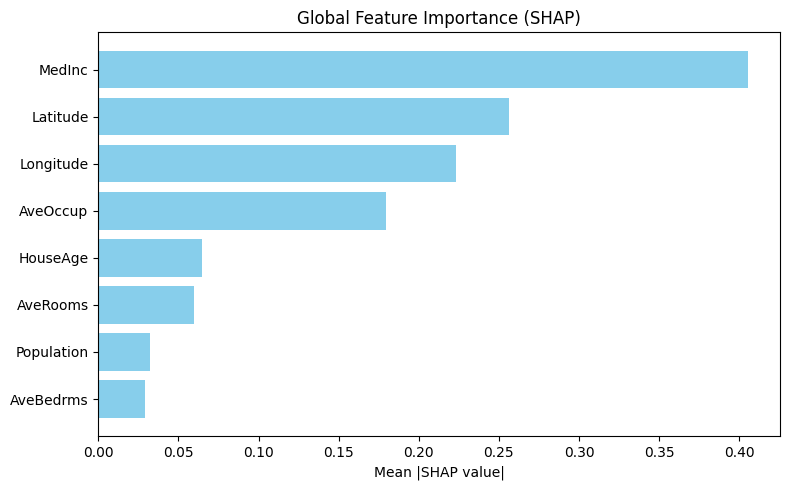

In [46]:
bins = 6
random_value = 420
max_depth = 10000

clf, accuracy, domains, X = train_tree_for_California(100000, random_value, bins, random_value, 100*bins)

explainer = shap.Explainer(clf, X)
shap_values = explainer(X)

# Global importance: mean absolute SHAP per feature
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

# If classification: take one class or sum across classes
if len(mean_abs_shap.shape) == 2:
    # Shape is (n_features, n_classes) → sum across classes
    mean_abs_shap = mean_abs_shap.sum(axis=1)

feature_names = list(domains.keys())

# Sort features by importance
sorted_indices = np.argsort(mean_abs_shap)[::-1]
sorted_shap = mean_abs_shap[sorted_indices]
sorted_names = np.array(feature_names)[sorted_indices]

# Plot
plt.figure(figsize=(8, 5))
plt.barh(sorted_names[::-1], sorted_shap[::-1], color="skyblue")
plt.xlabel("Mean |SHAP value|")
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

## Tests

In [6]:
# Mini test of counting
false = Node("False", 0, None, None)
true = Node("True", 1, None, None)
x1 = Node("x", 1.5, deepcopy(true), deepcopy(false))
x2 = Node("x", 0.5, deepcopy(true), x1)
y = Node("y", 0.5, deepcopy(false), deepcopy(true))
z = Node("z", 0.5, x2, y)

domains = {}
domains["x"] = (0, 2)
domains["y"] = (0, 1)
domains["z"] = (0, 1)

tree = Tree(z, domains)

tree.domains
tree.count()

print(f'Correct answer is 7, output was {tree.count()}')

# Minitest of negation
tree_to_negate = deepcopy(tree)
acum = tree_to_negate.count()
print(f'Correct answer is 7, output was {tree.count()}')

tree_to_negate.negate()
acum += tree_to_negate.count()

print(f'Correct answer is 12, output was {acum}')

# Minitest of conjunction
same_tree = deepcopy(tree)
same_tree_2 = deepcopy(tree)
same_tree_3 = deepcopy(tree)
opposite_tree = deepcopy(tree)

same_tree_3.conjunction(same_tree)
print(f'Correct answer is 7, output was {tree.count()}')

opposite_tree.negate()
same_tree_2.conjunction(opposite_tree)
print(f'Correct answer is 0, output was {same_tree_2.count()}')

# Minitest of conditioning
tree_to_condition = deepcopy(tree)
tree_to_condition.condition("z", 0)
print(f'Correct answer is 8, output was {tree_to_condition.count()}')

tree_to_condition = deepcopy(tree)
tree_to_condition.condition("z", 1)
print(f'Correct answer is 6, output was {tree_to_condition.count()}')

tree_to_condition = deepcopy(tree)
tree_to_condition.condition("x", 1)
print(f'Correct answer is 9, output was {tree_to_condition.count()}')

tree_to_condition = deepcopy(tree)
tree_to_condition.condition("x", 1)
tree_to_condition.condition("y", 1)
print(f'Correct answer is 12, output was {tree_to_condition.count()}')

Correct answer is 7, output was 7
Correct answer is 7, output was 7
Correct answer is 12, output was 12
Correct answer is 7, output was 7
Correct answer is 0, output was 0
Correct answer is 8, output was 8
Correct answer is 6, output was 6
Correct answer is 9, output was 9
Correct answer is 12, output was 12
